In [11]:
import importlib
from preprocess import Preprocess
import numpy as np
import MLP as mlp_module
from callbacks import EarlyStopping, ReduceLRONPlateau

importlib.reload(mlp_module)
MLP = mlp_module.MLP

In [2]:
rng = np.random.default_rng(7)
X = rng.normal(size=(200, 2))
y = rng.integers(0, 2, size=(200, 1)).astype(float)

X_train, X_val = X[:160], X[160:]
y_train, y_val = y[:160], y[160:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("classes:", np.unique(y_train))

X_train: (160, 2)
y_train: (160, 1)
X_val: (40, 2)
classes: [0. 1.]


In [12]:
from preprocess import Preprocess

In [50]:
data = Preprocess('data/dataset_2.json')
data.standard_scaler()
X, y = data.return_data()

In [51]:
n = len(X)
prop = int(n * 0.8) # 80 de treino e 20 val

In [52]:
y = np.asarray(y)
if y.ndim == 1:
    y = y.reshape(-1, 1)

X_train, X_val = X[:prop], X[prop:]
y_train, y_val = y[:prop], y[prop:]

In [ ]:
callbacks = []
callbacks.append(EarlyStopping(15, True, 1e-3))
callbacks.append(ReduceLRONPlateau(patience=15, factor=0.2))
layers = [2, 3]

model = MLP([X_train.shape[1], 2, y_train.shape[1]], "relu", 42, "bce")

model.train(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=1000,
    lr=0.01,
    metrics=["accuracy"],
    verbose_every=10,
    Callbacks=callbacks
)

print("loss final de treino:", model.loss_history_train[-1])
print("loss final de validação:", model.loss_history_val[-1])

época    0 | train_loss: 1.1291| val_loss: 1.3375 | train_accuracy: 0.5167 | val_accuracy: 0.5000|
época   10 | train_loss: 1.1241| val_loss: 1.3306 | train_accuracy: 0.5167 | val_accuracy: 0.5000|
época   20 | train_loss: 1.1192| val_loss: 1.3238 | train_accuracy: 0.5167 | val_accuracy: 0.5000|
época   30 | train_loss: 1.1144| val_loss: 1.3171 | train_accuracy: 0.5188 | val_accuracy: 0.5000|
época   40 | train_loss: 1.1096| val_loss: 1.3104 | train_accuracy: 0.5188 | val_accuracy: 0.5000|
época   50 | train_loss: 1.1048| val_loss: 1.3038 | train_accuracy: 0.5167 | val_accuracy: 0.5000|
época   60 | train_loss: 1.1001| val_loss: 1.2973 | train_accuracy: 0.5167 | val_accuracy: 0.5000|
época   70 | train_loss: 1.0954| val_loss: 1.2908 | train_accuracy: 0.5146 | val_accuracy: 0.5083|
época   80 | train_loss: 1.0908| val_loss: 1.2843 | train_accuracy: 0.5146 | val_accuracy: 0.5083|
época   90 | train_loss: 1.0862| val_loss: 1.2780 | train_accuracy: 0.5125 | val_accuracy: 0.5083|
época  100

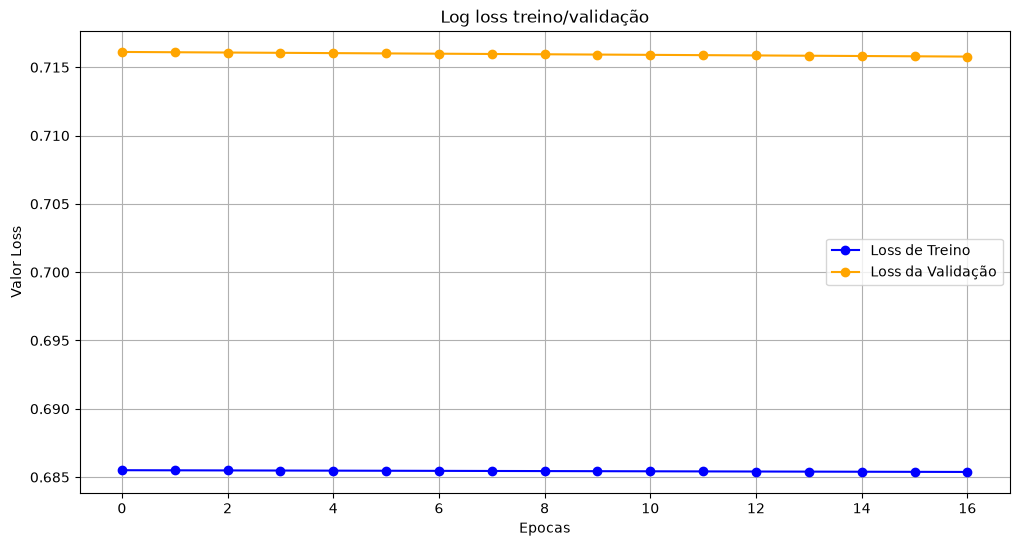

In [69]:
model.plot_train_val_loss()